# Autoevaluación de generación de antecedentes del FIS de Sugeno.
*Se tienen los siguientes datos de la evolución del COVID-19 en China durante 2020:*

[5,	6,	4,	7,	9,	6,	7,	4,	8,	16,	9,	14,	9,	15,	7,	11,	22,	17,	23,	27,	28,	30,	31,	37,	32,	42,	35,	47,	44,	29,	52,	70,	150,	98,	109,	118,	112,	139,	98,	105,	142,	143,	13,	254,	97,	108,	97,	89,	86,	73,	72,	66,	65,	57,	45,	46,	43,	38,	26,	25,	25,	15,	15,	9,	0,	11,	3,	0,	1,	0,	0,	0,	1,	0,	0,	0,	1,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0]

1. Aplicar un método de cluster, por ejemplo Fuzzy C Means para encontrar dos centros de cluster.
2. Calcular el ancho de las funciones de pertenencia utilizando la fórmula que aparece en el video anterior.
3. Graficar las dos gaussianas con el centro y dispersión asociados a los clusters hallados.
4. Repita para 3 clusters.

In [2]:
pip install -U scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\Usuario PC\Desktop\Thiago\CURSANDO\2025\2do Cuatri\Inteligencia Artificial\IA2026\Scikit-learn\sklearn-env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

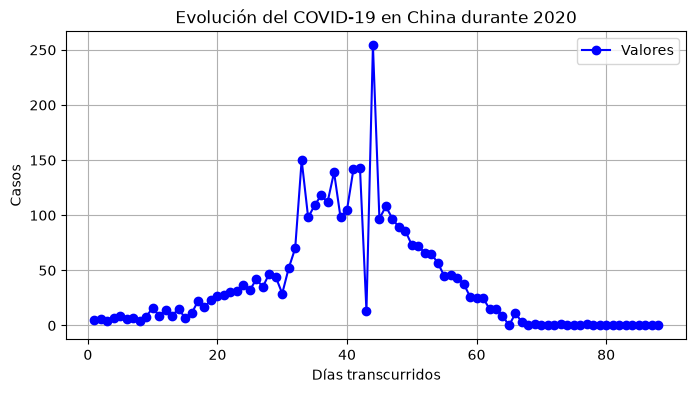

In [4]:
data = [5,	6,	4,	7,	9,	6,	7,	4,	8,	16,	9,	14,	9,	15,	7,	11,	22,	17,	23, 
        27,	28,	30,	31,	37,	32,	42,	35,	47,	44,	29,	52,	70,	150, 98, 109, 118,
        112, 139, 98, 105, 142, 143, 13, 254, 97, 108, 97, 89, 86, 73, 72, 66, 65,
        57,	45,	46,	43,	38,	26,	25,	25,	15,	15,	9,	0,	11,	3,	0,	1,	0,	0,	0,
        1,	0,	0,	0,	1,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0]

colors = ['b', 'orange', 'g', 'r', 'c', 'm', 'y', 'k', 'Brown', 'ForestGreen']

xpts = np.arange(1, len(data) + 1)
ypts = np.array(data)


# Creación del gráfico
plt.figure(figsize=(8, 4))
plt.plot(xpts, ypts, marker='o', linestyle='-', color='b', label='Valores')

# Personalización básica
plt.title('Evolución del COVID-19 en China durante 2020')
plt.xlabel('Días transcurridos')
plt.ylabel('Casos')
plt.grid(True)
plt.legend()

# Mostrar la figura
plt.show()

1° Luego de graficar los datos, tenemos que hallar los centros de cluster, aplicando un método, como por ejemplo Fuzzy C-Means.

(2, 88)


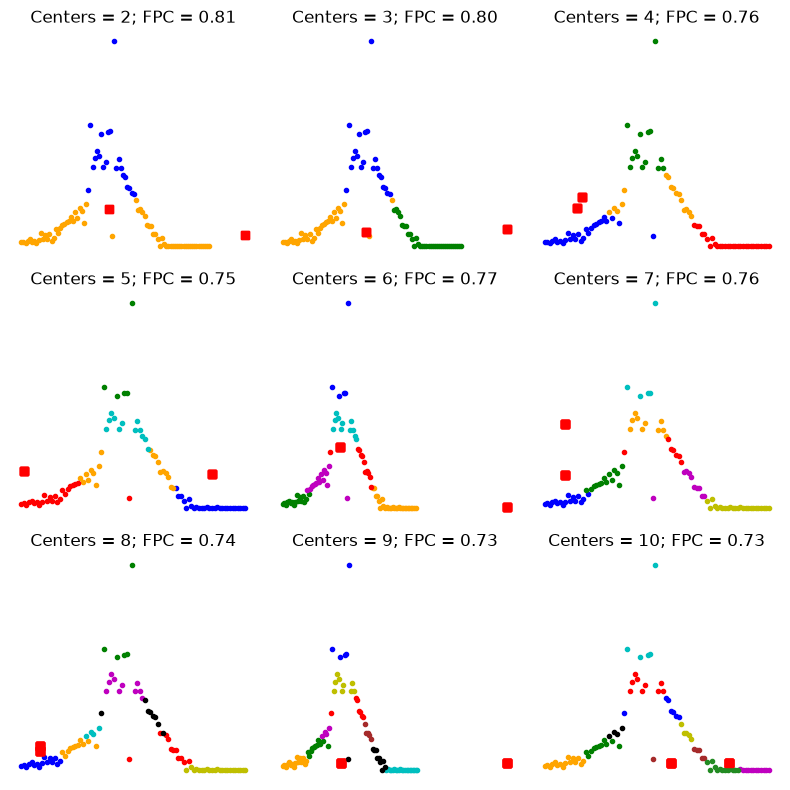

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(8,8))
datapoints = np.vstack((xpts, ypts))
print(datapoints.shape)
fpcs = []

for ncenters, ax in enumerate(axs.reshape(-1), 2):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        datapoints, ncenters, m=2, error=0.005, maxiter=1000, init=None)

    fpcs.append(fpc)

    cluster_membership = np.argmax(u, axis=0)
    for j in range(ncenters):
        ax.plot(xpts[cluster_membership == j],
                ypts[cluster_membership == j], '.', color=colors[j])
        ax.plot(cntr[0], cntr[1], 'sr')

    ax.set_title('Centers = {0}; FPC = {1:.2f}'.format(ncenters, fpc))
    ax.axis('off')
    fig.tight_layout()
    

In [17]:
# Calculemos entonces los clusters para n=2

# Pero antes, vamos a normalizar los datos.
from sklearn.preprocessing import MinMaxScaler

valores = np.array(data, dtype=float).reshape(-1, 1)

print(valores.shape)
# (88, 1)

scaler = MinMaxScaler()
valores_norm = scaler.fit_transform(valores)

print(valores_norm.shape)
# (88, 1)

# Formato requerido por skfuzzy:
# (variables, muestras)
datos_fcm = valores_norm.T

print(datos_fcm.shape)
# (1, 88)
cantidad_clusters = 2

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    datos_fcm,
    c=cantidad_clusters,
    m=2,
    error=0.005,
    maxiter=1000,
    seed=42
)

print("Forma de los centros:", cntr.shape)
print("Centros normalizados:")
print(cntr)

print("FPC:", fpc)

(88, 1)
(88, 1)
(1, 88)
Forma de los centros: (2, 1)
Centros normalizados:
[[0.43233612]
 [0.05565598]]
FPC: 0.9073878677351139


In [8]:
print(u)
print(cntr)
cluster_membership = np.argmax(u, axis=0)
print(cluster_membership)
print(len(u))
print(len(cluster_membership))

[[9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 5.00000026e-01 5.00000026e-01 6.68357508e-05
  6.68357508e-05 9.99933164e-01 6.68357508e-05 9.99933164e-01
  6.68357508e-05 9.99933164e-01 6.68357508e-05 6.68357508e-05
  9.99933164e-01 6.68357508e-05 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 6.68357508e-05 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 6.68357508e-05 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 9.99933164e-01 9.99933164e-01
  9.99933164e-01 9.99933164e-01 6.68357508e-05 6.68357508e-05
  6.68357508e-05 6.68357508e-05 6.68357508e-05 6.68357508e-05
  6.68357508e-05 6.68357508e-05 6.68357508e-05 6.68357508e-05
  6.6835

2° Calcular el ancho de las funciones de pertenencia utilizando la fórmula que aparece en el video anterior.
sigma𝑖 = (radio de influencia) * (max(𝑥𝑖) − min(𝑥𝑖))/raiz(8)

Dado que por fuzzy c-means obtuvimos nclusters=2, debemos calcular 2 sigmas.



In [18]:
radio = 0.5

sigma_norm = radio / np.sqrt(8)

print("Sigma normalizado:", sigma_norm)

Sigma normalizado: 0.17677669529663687


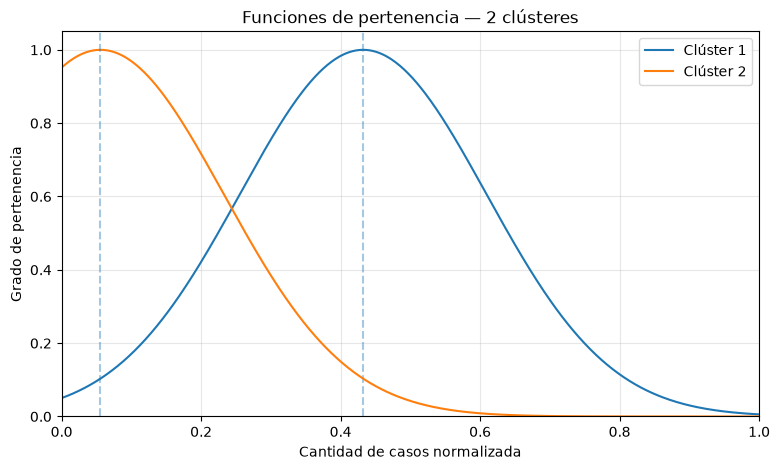

In [19]:
x = np.linspace(0, 1, 500)

plt.figure(figsize=(9, 5))

for cluster in range(cantidad_clusters):

    centro = cntr[cluster, 0]

    pertenencia = fuzz.gaussmf(
        x,
        mean=centro,
        sigma=sigma_norm
    )

    plt.plot(
        x,
        pertenencia,
        label=f"Clúster {cluster + 1}"
    )

    plt.axvline(
        centro,
        linestyle="--",
        alpha=0.4
    )

plt.title("Funciones de pertenencia — 2 clústeres")
plt.xlabel("Cantidad de casos normalizada")
plt.ylabel("Grado de pertenencia")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Graficarlas en cantidad de casos original

Esto puede resultar más fácil de interpretar.

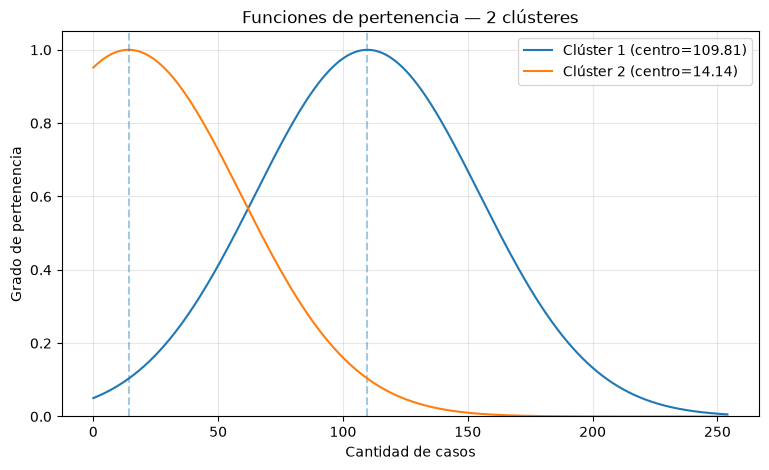

In [21]:
centros_originales = scaler.inverse_transform(cntr).ravel()

rango_original = valores.max() - valores.min()

sigma_original = (
    radio * rango_original / np.sqrt(8)
)

x_original = np.linspace(
    valores.min(),
    valores.max(),
    500
)

plt.figure(figsize=(9, 5))

for cluster, centro in enumerate(centros_originales):

    pertenencia = fuzz.gaussmf(
        x_original,
        mean=centro,
        sigma=sigma_original
    )

    plt.plot(
        x_original,
        pertenencia,
        label=(
            f"Clúster {cluster + 1} "
            f"(centro={centro:.2f})"
        )
    )

    plt.axvline(
        centro,
        linestyle="--",
        alpha=0.4
    )

plt.title("Funciones de pertenencia — 2 clústeres")
plt.xlabel("Cantidad de casos")
plt.ylabel("Grado de pertenencia")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def calcular_y_graficar(cantidad_clusters, radio=0.5):

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        datos_fcm,
        c=cantidad_clusters,
        m=2,
        error=0.005,
        maxiter=1000,
        seed=42
    )

    sigma = radio / np.sqrt(8)
    x = np.linspace(0, 1, 500)

    plt.figure(figsize=(9, 5))

    for cluster in range(cantidad_clusters):

        centro = cntr[cluster, 0]

        mu = fuzz.gaussmf(
            x,
            mean=centro,
            sigma=sigma
        )

        plt.plot(
            x,
            mu,
            label=f"Clúster {cluster + 1}"
        )

        plt.axvline(
            centro,
            linestyle="--",
            alpha=0.4
        )

    plt.title(
        f"Funciones de pertenencia — "
        f"{cantidad_clusters} clústeres"
    )
    plt.xlabel("Cantidad de casos normalizada")
    plt.ylabel("Grado de pertenencia")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return cntr, u, fpc